# Sensitivities

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from cr3bp import (
    create_earth_moon_system,
    sweep_1d,
    evaluate,
    file_path,
    plot_1d
    )

### Initialize the System / Problem

In [2]:
# Create the Earth-Moon system using the cr3bp module
em = create_earth_moon_system()

In [3]:
# Define the LEO and LMO altitudes in meters
leo_alt_m=463e3
lmo_alt_m=100e3

### Load the Optimals

In [4]:
optimals = np.load(f"{file_path}/optimals_iteration3.npy")
optimal_theta, optimal_delta_v, optimal_delta_v_angle, optimal_tof = optimals
print(f"Optimal theta: {optimal_theta}")
print(f"Optimal delta_v: {optimal_delta_v}")
print(f"Optimal delta_v_angle: {optimal_delta_v_angle}")
print(f"Optimal tof: {optimal_tof}")

Optimal theta: 3.969615650969529
Optimal delta_v: 3.0248441828254844
Optimal delta_v_angle: 0.074609375
Optimal tof: 0.7299271700356719


In [5]:
constraint, objective = evaluate(em, optimals, leo_alt_m, lmo_alt_m)
print(f"Constraint value: {constraint}")
print(f"Objective value: {objective}")

print(f"Constraint Value in km: {constraint * em.l_star * 1e-3}")
print(f"Objective Value in km/s: {objective * em.v_star * 1e-3}")

Constraint value: -4.48354203363803e-07
Objective value: 3.3171211191891916
Constraint Value in km: -0.17234735577304588
Objective Value in km/s: 3.3984880010688


In [6]:
theta_delta = 0.002

delta_v_delta = 0.002

delta_v_angle_delta = 0.001

tof_delta = 0.001

### Sensitivity Function

In [7]:
def run_sensitivity_1d(param1, delta1, grid_size=5001):
    """
    Load or compute a 1D sensitivity sweep, find the minimum, and plot.

    Parameters
    ----------
    param1 : str   Variable name ('theta', 'delta_v', 'delta_v_angle', 'tof')
    delta1 : float Perturbation half-range for the variable
    grid_size      : int   Grid resolution (default 201)

    Returns
    -------
    pd.DataFrame  The full sweep results
    """
    cache_path = Path(f"{file_path}/{param1}_sweep.npy")

    if cache_path.exists():
        print(f"Loading cached {param1} sweep...")
        df = pd.DataFrame(
            np.load(cache_path),
            columns=['theta', 'delta_v', 'delta_v_angle', 'tof', 'total_delta_v', 'distance_to_lmo']
        )
    else:
        print(f"Computing {param1} sweep...")
        df = sweep_1d(em, param1, delta1, grid_size, optimals, leo_alt_m, lmo_alt_m)
        np.save(cache_path, df.values)

    min_row = df.loc[df['total_delta_v'].idxmin()]
    print(f"  min Δv = {min_row['total_delta_v']:.6f},  dist to LMO = {min_row['distance_to_lmo']:.6e}")

    plot_1d(df, param1, optimals)
    return df

## Results

### Theta 

Loading cached theta sweep...
  min Δv = 3.316243,  dist to LMO = -2.757666e-06


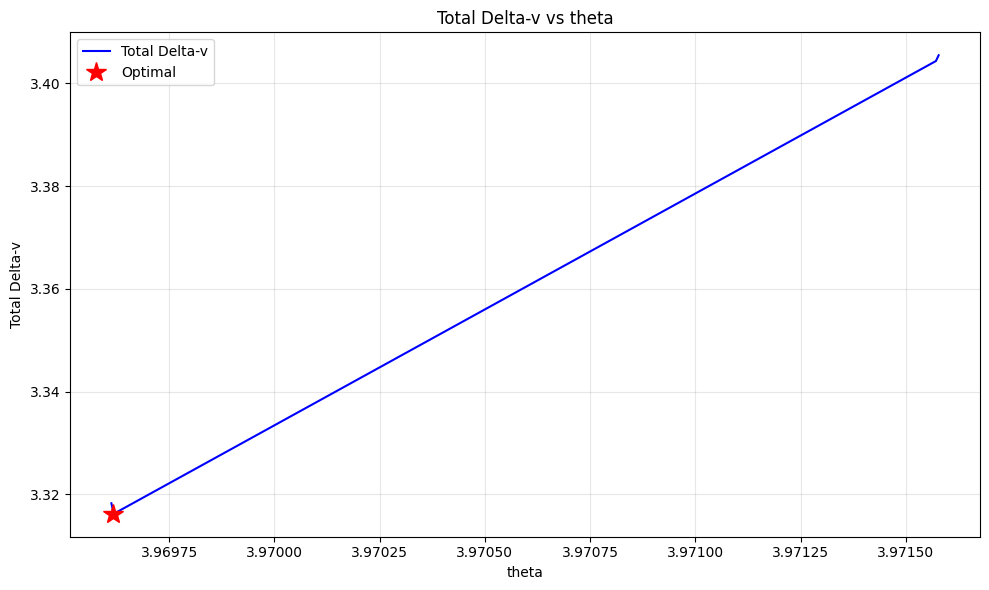

False


In [ ]:
theta_sweep = run_sensitivity_1d('theta', theta_delta)

### Delta_v

In [ ]:
delta_v_sweep = run_sensitivity_1d('delta_v', delta_v_delta)

### Alpha

In [ ]:
alpha_sweep = run_sensitivity_1d('delta_v_angle', delta_v_angle_delta)

Computing delta_v_angle sweep...
Performing grid search with 1 x 1 x 5001 x 1 = 5001 grid points...


### ToF

Loading cached theta vs tof sweep...
  min Δv = 3.110120,  dist to LMO = 2.224002e-06


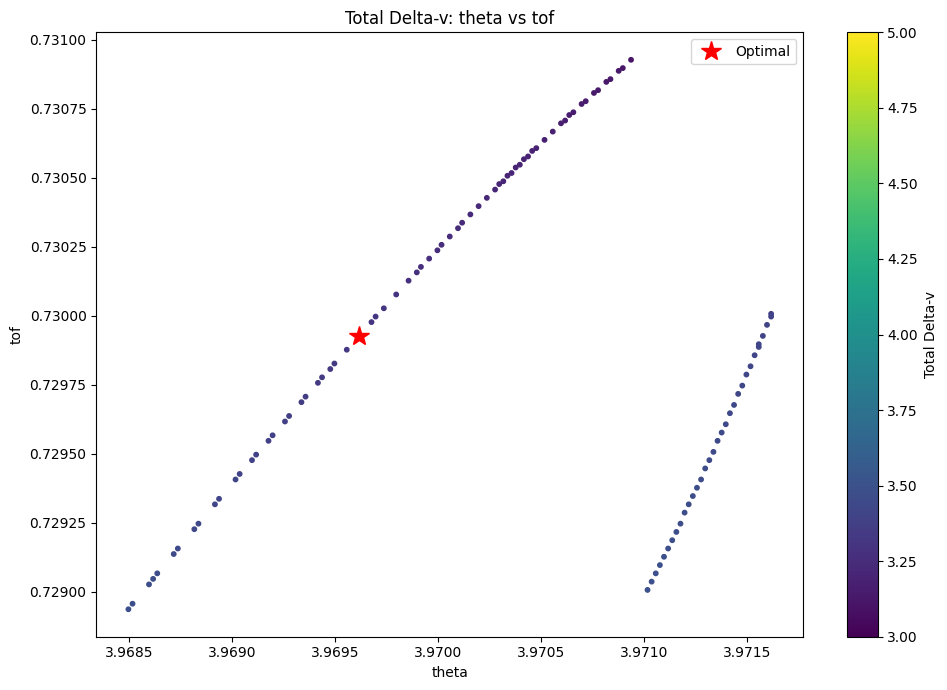

In [ ]:
tof_sweep = run_sensitivity_1d('tof', tof_delta)